# Лабораторная №1 курса "Синтез Речи"

## EDA

### Импорты и константы

In [ ]:
import json
import re
import string
from collections import Counter, defaultdict
from pprint import pprint

import emoji
import matplotlib.pyplot as plt
import pandas as pd
import regex
from babel.numbers import get_currency_symbol, list_currencies
from tqdm import tqdm


In [136]:
RUSLAN_METADATA_PATH = "../../data/metadata_RUSLAN_22200.csv"
RANDOM_STATE = 42

### Читаем RUSLAN метадату

In [137]:
RUSLAN_METADATA = pd.read_csv(RUSLAN_METADATA_PATH, sep="|", header=None, index_col=0)
RUSLAN_METADATA.head()

,1
0,
000000_RUSLAN,С тревожным чувством берусь я за перо.
000001_RUSLAN,Кого интересуют признания литературного неудач...
000002_RUSLAN,Что поучительного в его исповеди?
000003_RUSLAN,Да и жизнь моя лишена внешнего трагизма.
000004_RUSLAN,Я абсолютно здоров.


### Для сокращений и аббревиатур будем использовать [ГПНТБ словарь](https://www.gpntb.ru/2017-08-21-14-53-51/339-produkty-gpntb/7630-elektronnyj-slovar-standartizovannykh-sokrashchenij.html)

In [138]:
SHORT_FORMS_ABBREVIATIONS_PATH = "data/short_forms.dict"

In [139]:
short_forms_abbreviations_df = pd.read_csv(SHORT_FORMS_ABBREVIATIONS_PATH)
# Убираем все, кроме пар {сокращение: слово/словосочетание}
short_forms_abbreviations_df = short_forms_abbreviations_df[
    ["Слово (словосочетание)", "Сокращение"]
]
short_forms_abbreviations_df = short_forms_abbreviations_df.dropna()

#### Нормализуем пробелы

In [140]:
def normalize_spaces(input_string):
    return re.sub(r'\s+', ' ', input_string).strip()

In [141]:
short_forms_abbreviations_df["Слово (словосочетание)"] = short_forms_abbreviations_df[
    "Слово (словосочетание)"
].apply(normalize_spaces)

short_forms_abbreviations_df["Сокращение"] = short_forms_abbreviations_df[
    "Сокращение"
].apply(normalize_spaces)

short_forms_abbreviations_df.head(5)

,Слово (словосочетание),Сокращение
0,например,напр.
1,сравнение; сравни,ср.
2,Германская Демократическая Республика,ГДР
3,Всемирный совет мира,ВСМ
4,Всемирная организация здравоохранения,ВОЗ


#### Разделяем сокращения и аббревиатуры

In [142]:
def separate_short_forms_abbreviations(df: pd.DataFrame):
    """
    Разделять по КАПСУ нет смысла, есть одиночные сокращения типа `С`.
    Ну и плюс, вдруг там будут какие-нибудь сокращения капсом лучше брать так: 
    все, что с точкой на конце – сокращения; все, что нет – аббревиатуры
    """
    short_forms = {}
    abbreviations = {}
    for row in df.iterrows():
        candidate = row[1]["Сокращение"]
        if "." in candidate or "-" in candidate:
            short_forms[row[1]["Сокращение"]] = row[1]["Слово (словосочетание)"]
        else:
            abbreviations[row[1]["Сокращение"]] = row[1]["Слово (словосочетание)"]
    return short_forms, abbreviations

In [143]:
short_forms_dict, abbreviations_dict = separate_short_forms_abbreviations(
    short_forms_abbreviations_df
)

In [144]:
short_forms_list = short_forms_dict.keys()
abbreviations_list = abbreviations_dict.keys()

In [145]:
abbreviations_list

dict_keys(['ГДР', 'ВСМ', 'ВОЗ', 'США', 'ВФП', 'ВНР', 'ИСО', 'ИФЛА', 'ВМО', 'МОТ', 'ФАО', 'МАгАтЭ', 'МФД', 'НРБ', 'ООН', 'ЮНЕСКО', 'ЧССР', 'ПНР', 'ФРГ', 'ОЭСР', 'СРР', 'вуз', 'С', 'км', 'г', 'З', 'кВт', 'к/с', 'АО', 'ПВ', 'ч', 'сут', 'мфише҆', '№', 'мин', 'нп', 'К°; Ко', 'Ю', 'В', 'bokbd', 'bd', 'billedfonogr', 'AS', 'AD', 'AB', 'AG', 'Ko', 'ko', 'letop', 'ezds', 'FID', 'FIAB', 'dr', 'ČSSR', 'cm', 'FSM', 'IAEA', 'afr', 'ca', 'hbd', 'hung', 'hullbd', 'indledn', 'ISO', 'ILO', 'IFLA', 'FAO', 'mficha', 'mfiche', 'mfișă', 'Mfiche', 'mforma', 'mfiš', 'mfisza', 'NV', 'MNK', 'mtárs', 'Mij', 'OMM', 'OECD', 'OIT', 'OY', 'ps', 'PRL', 'OCDE', 'UNESCO', 'OMS', 'OAA', 'ко', 'мфиш', 'obst', 'nr', 'no', 'obál', 'Obst', 'st', 'SA', 'RSR', 'ONU', 'sloven', 'wg', 'Ztg', 'tr', 'Zsstellung', 'Zsfassung', 'broš', 'co', 'BRD', 'cuad', 'WFTU', 'WHO', 'WPC', 'WMO', 'db', 'diamficha', 'cie', 'DDR', 'CMP', 'см', 'цм', 'обра', 'АД', 'сие', 'вж', 'ВИ', 'РГ', 'UN', 'USA', 'ua', 'h', 'Hz', 'Pa', 'pc', 'H', 'д; d', 'p

#### Междометия

In [146]:
with open("data/interjections.json", encoding="utf-8") as f:
    interjections = json.load(f)

#### Множество валютных знаков и обозначений

In [147]:
currencies_code = list_currencies()
currencies_symbols = {
    get_currency_symbol(currency, locale="en_US")
    for currency in currencies_code
}

currencies = currencies_code | currencies_symbols

### Считаем статистику по фразам в корпусе RUSLAN

In [148]:
# Группы название – паттерн для типичных поисков
patterns = {
    "dates": r"\b(?:0?[1-9]|[12]\d|3[01])[\./-](?:0?[1-9]|1[0-2])[\./-](?:\d{2}|\d{4})\b",
    "phone_numbers": r"(?:\+7|8)[\s().-]*(?:\d[\s().-]*){10}",
    "ordinal_numbers": r"\b\d+-?(?:й|ый|ой|я|ая|ое|ее|е|ые|ие|ых|их|ым|им|ом|ем|му|ему|ую|ю|го|ого|ей|ими|ыми|ми|м|и)\b",
    "technical": r"[*|/@+<>=\\^~_{}\[\]]",
    "punct_runs": r"(?<![.!?])(?!\?!|\?.\.|\.\.\.)[.!?]{2,}",
    "space_before_comma": r"\s+,",
    "space_after_comma": r",(?:\s{2,}|(?=\S|$))",
    "spaces_run": r"\s{2,}",
    "wrong_quot_marks": r"[“”„‟‹›„““”]",
    "unfinished_quot_marks": r"(\"(=!.+\")|\'(=!.+\')|«(=!.+»))",
    # "russian_smiling_parenthesis": r"^[^(]*\)+",
}

#### Класс-счетчик

In [149]:
class EntryStatistics:
    def __init__(self, input_string):
        self.input_string = input_string
        self.input_string_preprocessed = self.preprocess(self.input_string)
        self.input_string_tokenized = self.input_string.split()
        self.input_string_preprocessed_tokenized = self.input_string_preprocessed.split()

        self.len_chars = len(self.input_string)
        self.len_words = len(self.input_string_tokenized)

        self.dict_of_counters = self.build_dict_of_counters()
        self.vector = self.build_vector()

    def build_dict_of_counters(self):
        return {
            # Типичные
            "dates": self.regex_find(patterns["dates"]),
            "phone_numbers": self.regex_find(patterns["phone_numbers"]),
            "ordinal_numbers": self.regex_find(patterns["ordinal_numbers"]),
            "technical": self.regex_find(patterns["technical"]),
            "punct_runs": self.regex_find(patterns["punct_runs"]),
            "space_before_comma": self.regex_find(patterns["space_before_comma"]),
            "space_after_comma": self.regex_find(patterns["space_after_comma"]),
            "spaces_run": self.regex_find(patterns["spaces_run"]),
            "wrong_quot_marks": self.regex_find(patterns["wrong_quot_marks"]),
            "unfinished_quot_marks": self.regex_find(patterns["unfinished_quot_marks"]),
            # "russian_smiling_parenthesis": self.regex_find(patterns["russian_smiling_parenthesis"]),
            # Нетипичные
            "numerals": self.get_numerals(),
            "currency": self.get_currency(),
            "non_cyrillic": self.get_non_cyrillic(),
            "short_forms": self.get_short_forms(),
            "special_symbols": self.get_special_symbols(),
            "abbreviations": self.get_abbreviations(),
            "interjections": self.get_interjections(),
            "emoji": self.get_emoji()
        }
    
    def build_vector(self):
        return [
            sum(counter.values()) / (self.len_chars + 1) 
            for counter in self.dict_of_counters.values()
        ]
    
    def preprocess(self, input_string):
        input_string = input_string.lower()
        input_string = input_string.translate(str.maketrans("", "", string.punctuation))
        return input_string

    def regex_find(self, pattern) -> Counter:
        matches = re.findall(pattern, self.input_string)
        matches_count = Counter(matches)

        return matches_count

# Нетипичные поиски
    def get_numerals(self) -> Counter:
        pattern = r'-?\d*\.?\d+'
        matches = re.findall(pattern, self.input_string)
        matches = [float(x) if '.' in x else int(x) for x in matches]
        matches_count = Counter(matches)

        return matches_count

    def get_currency(self):
        pattern = r"(?<!\w)(?:" + "|".join(
            re.escape(currency)
            for currency in sorted(currencies, key=len, reverse=True)
        ) + r")(?!\w)"
        matches = re.findall(pattern, self.input_string)
        matches_count = Counter(matches)

        return matches_count

    def get_non_cyrillic(self):
        matches = [
            char
            for char in self.input_string
            if regex.fullmatch(r"[\p{L}]", char)
            and not regex.fullmatch(r"\p{Cyrillic}", char)
        ]
        matches_count = Counter(matches)

        return matches_count
    
    def get_short_forms(self):
        input_string = self.input_string.lower()
        short_forms = [
            (short_form, len(short_form))
            for short_form in short_forms_list
        ]

        matches = []

        i = 0
        while i < len(input_string):
            found = None
            found_length = 0
            for short_form, short_form_length in short_forms:
                if (
                    input_string.startswith(short_form, i)
                    and short_form_length > found_length
                ):
                    before = input_string[i - 1] if i > 0 else ""
                    after_idx = i + short_form_length
                    after = input_string[after_idx] if after_idx < len(input_string) else ""

                    # Проверяем границы
                    if (
                        not before.isalnum()
                        and not after.isalnum()
                    ):
                        found = short_form
                        found_length = short_form_length
            if found is not None:
                matches.append(found)
                i += found_length
            else:
                i += 1

        return Counter(matches)

    def get_abbreviations(self):
        def preprocess_punct(input_string):
            return input_string.translate(
                str.maketrans("", "", string.punctuation)
            )

        tokens = self.input_string_tokenized
        matches = []
        for idx, token in enumerate(tokens):
            abbreviation = preprocess_punct(token)
            if abbreviation not in abbreviations_list:
                continue
            # Однобуквенное слово не считаем аббревиатурой
            if len(abbreviation) == 1 or abbreviation.islower():
                continue
            # Исключаем инициалы
            if (
                len(abbreviation) == 1
                and idx > 0
                and (
                    tokens[idx - 1] == "."
                    or tokens[idx - 1].endswith(".")
                )
            ):
                continue
            matches.append(abbreviation)

        return Counter(matches)

    def get_special_symbols(self):
        pattern = r'.,!?"\';…:\-—«»\u0301*|/@+<>=\\^~_{}\[\]'
        # \u0301 = " ́"
        matches = regex.findall(rf"[^\p{{L}}\p{{N}}\s{pattern}]", self.input_string)
        matches_count = Counter(matches)

        return matches_count

    def get_interjections(self):
        STRIP = string.punctuation + "…«»—"
        tokens = {token.strip(STRIP).lower() for token in self.input_string_tokenized}
        matches = [i for i in interjections if i.lower() in tokens]
        matches_count = Counter(matches)

        return matches_count

    def get_emoji(self):
        matches = emoji.emoji_list(self.input_string)
        matches = [match["emoji"] for match in matches]
        matches_count = Counter(matches)

        return matches_count

#### Статистика

Посчитаем для каждого признака:

* общее число совпадений;
* число и долю фраз с совпадением;
* встречаемость на 1000 символов и на 1000 слов;
* 10 самых частых значений.

In [150]:
stats = defaultdict(Counter)
phrases_with_feature = Counter()
total_characters = RUSLAN_METADATA[1].str.len().sum()
total_words = RUSLAN_METADATA[1].str.split().str.len().sum()

In [151]:
for phrase in RUSLAN_METADATA.iterrows():
    entry_stats = EntryStatistics(phrase[1][1]).dict_of_counters
    
    for param, counter in entry_stats.items():
        stats[param] += counter
        phrases_with_feature[param] += bool(counter)

##### Сводная статистика

In [152]:
statistics = []
for feature, counter in stats.items():
    matches = sum(counter.values())
    phrases = phrases_with_feature[feature]
    statistics.append({
        "feature": feature,
        "matches": matches,
        "phrases": phrases,
        "phrase_share_percent": phrases / len(RUSLAN_METADATA) * 100,
        "per_1000_characters": matches / total_characters * 1000,
        "per_1000_words": matches / total_words * 1000,
    })

statistics_df = pd.DataFrame(statistics).set_index("feature")
statistics_df.sort_values("phrases", ascending=False).round(3)

,matches,phrases,phrase_share_percent,per_1000_characters,per_1000_words
feature,,,,,
special_symbols,13411,6994,31.505,7.478,50.228
punct_runs,395,382,1.721,0.220,1.479
short_forms,222,217,0.977,0.124,0.831
interjections,164,162,0.730,0.091,0.614
spaces_run,65,65,0.293,0.036,0.243
wrong_quot_marks,142,57,0.257,0.079,0.532
abbreviations,15,15,0.068,0.008,0.056
technical,7,5,0.023,0.004,0.026
space_after_comma,5,5,0.023,0.003,0.019


##### Топ-10 значений по каждому признаку

In [153]:
for feature, counter in stats.items():
    if counter:
        print(feature)
        pprint(counter.most_common(10))
        print()

technical
[('/', 4), ('*', 1), ('<', 1), ('>', 1)]

punct_runs
[('!..', 372),
 ('..', 16),
 ('?.', 2),
 ('!!!', 2),
 ('??', 1),
 ('!.', 1),
 ('.?', 1)]

space_after_comma
[(',', 5)]

spaces_run
[('  ', 62), ('   ', 2), ('     ', 1)]

wrong_quot_marks
[('„', 72), ('“', 57), ('”', 13)]

numerals
[(61, 1), (129, 1), (16, 1), (6, 1)]

short_forms
[('лет.', 39),
 ('год.', 24),
 ('прав.', 10),
 ('час.', 10),
 ('слов.', 9),
 ('в.', 8),
 ('с.', 8),
 ('г.', 6),
 ('поэт.', 6),
 ('м.', 6)]

special_symbols
[('–', 10410),
 ('‑', 2243),
 ('(', 305),
 (')', 305),
 ('„', 72),
 ('“', 57),
 ('”', 13),
 ('’', 6)]

abbreviations
[('США', 4),
 ('МГУ', 3),
 ('ООН', 2),
 ('НИИ', 2),
 ('ПТУ', 1),
 ('КПП', 1),
 ('СПбГУ', 1),
 ('ФИО', 1)]

interjections
[('ах', 28),
 ('увы', 26),
 ('эх', 14),
 ('э', 10),
 ('пардон', 10),
 ('ой', 9),
 ('ох', 7),
 ('ого', 7),
 ('м', 6),
 ('эй', 5)]



##### Графики

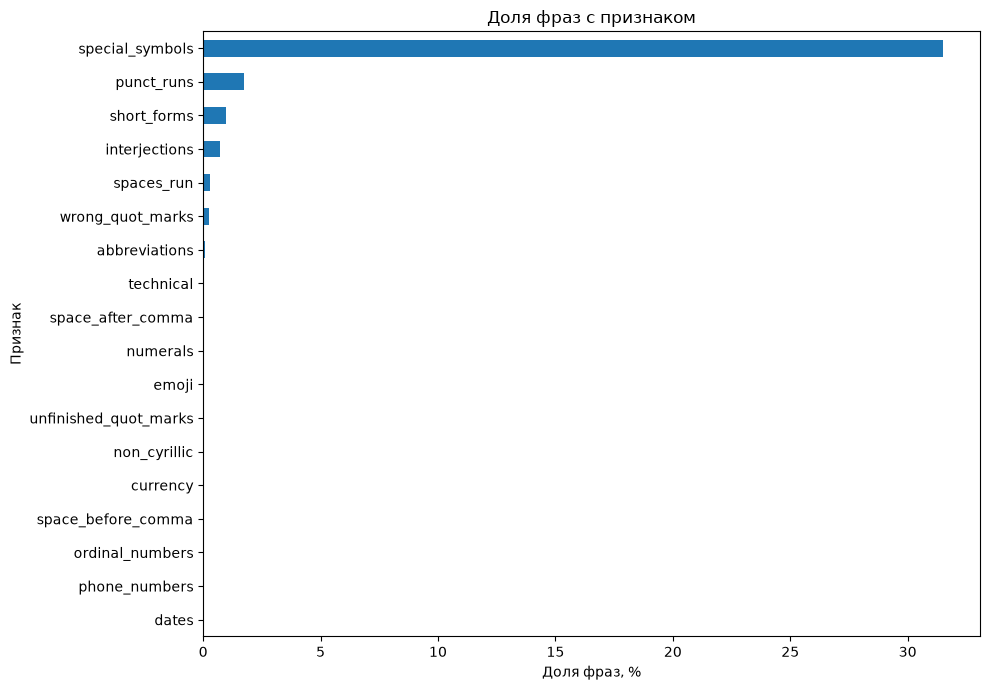

In [154]:
plot_data = statistics_df.sort_values("phrase_share_percent")

ax = plot_data["phrase_share_percent"].plot.barh(figsize=(10, 7))
ax.set_title("Доля фраз с признаком")
ax.set_xlabel("Доля фраз, %")
ax.set_ylabel("Признак")
plt.tight_layout()
plt.show()

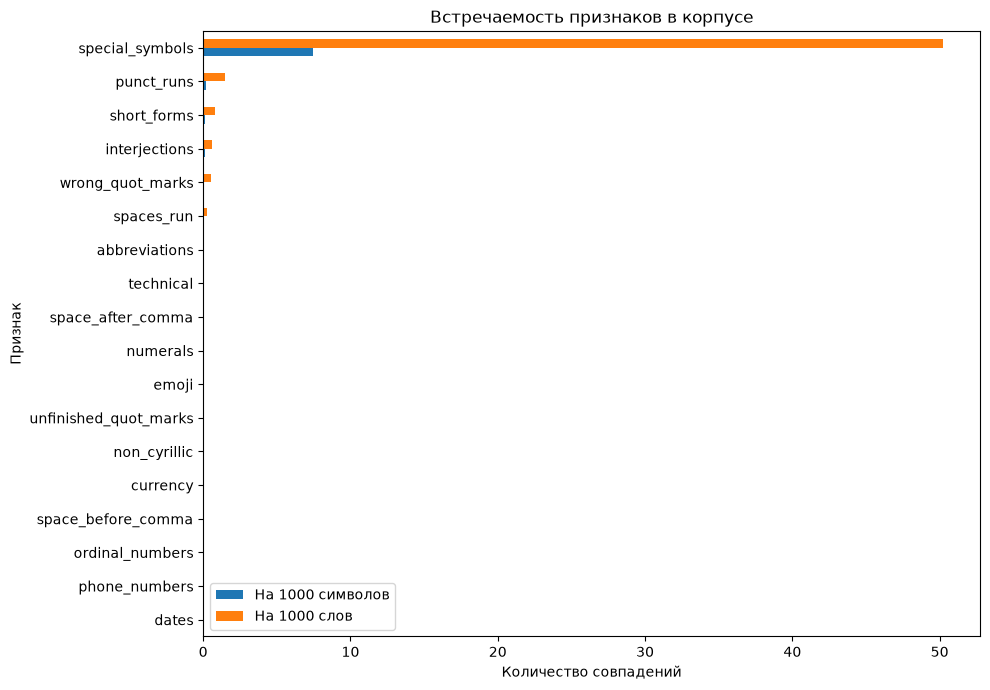

In [155]:
frequency_columns = ["per_1000_characters", "per_1000_words"]
ax = statistics_df[frequency_columns].sort_values("per_1000_words").plot.barh(
    figsize=(10, 7)
)
ax.set_title("Встречаемость признаков в корпусе")
ax.set_xlabel("Количество совпадений")
ax.set_ylabel("Признак")
ax.legend(["На 1000 символов", "На 1000 слов"])
plt.tight_layout()
plt.show()

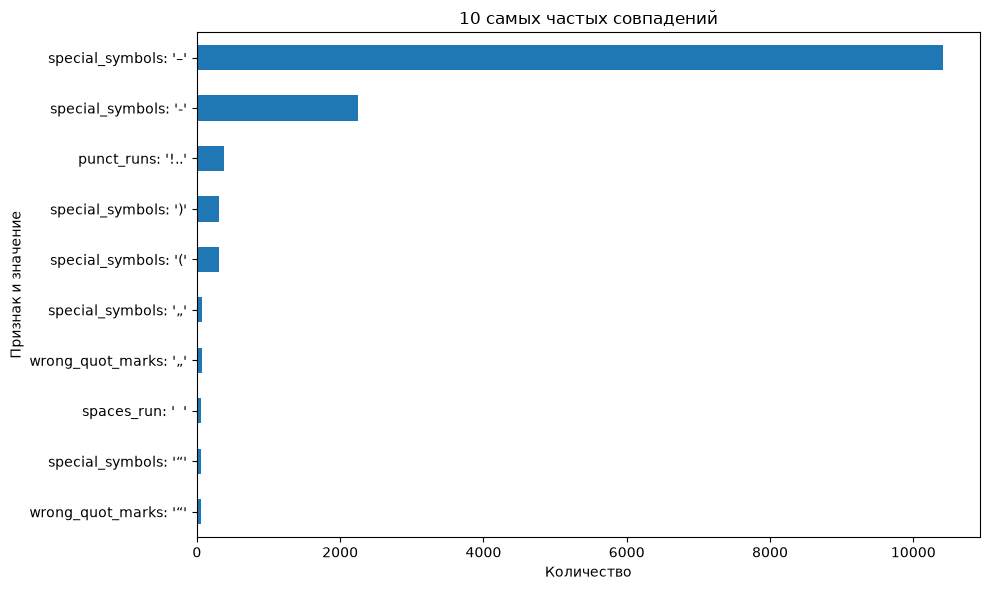

In [156]:
top_values = []
for feature, counter in stats.items():
    for value, count in counter.items():
        top_values.append((f"{feature}: {value!r}", count))

top_values = sorted(top_values, key=lambda item: item[1])[-10:]
labels, values = zip(*top_values)
ax = pd.Series(values, index=labels).plot.barh(figsize=(10, 6))
ax.set_title("10 самых частых совпадений")
ax.set_xlabel("Количество")
ax.set_ylabel("Признак и значение")
plt.tight_layout()
plt.show()

### Выводы

**Какие проблемы нашли в корпусе?**

Самая частая особенность корпуса связана с нестандартными тире и дефисами. Категория `special_symbols` встретилась в 6994 фразах, или в 31.51% корпуса. Основную часть составили короткое тире `–` с 10410 совпадениями и неразрывный дефис с 2243 совпадениями. Это систематическая особенность оформления текста, которую безопаснее исправлять нормализатором, а не удалением фраз.

Заметно реже встретились серии знаков препинания: 382 фразы, аббревиатуры: 413 фраз, сокращения: 217 фраз и междометия: 162 фразы. Неправильные кавычки найдены в 57 фразах, повторные пробелы в 65. Технические символы и цифры единичны. Даты, телефонные номера, валюты, некириллические буквы и эмодзи текущими правилами не найдены.

Статистику аббревиатур нужно интерпретировать осторожно: среди совпадений есть обычные слова и предлоги `В`, `С`, `ко` и `сие`. Поэтому полученные 1.86% являются верхней оценкой реальной доли аббревиатур.

**Что можно обозначить как выводы?**

1. Большая часть найденных особенностей исправляется простой заменой символов без изменения слов.
2. Редкие числа, сокращения, аббревиатуры и технические обозначения безопаснее отфильтровывать, потому что их раскрытие может не совпасть с аудио.
3. Основной объём корпуса можно сохранить после нормализации пунктуации и Unicode.

## Классификатор нормализован-не нормализован

### Иморты и константы

In [157]:
import warnings
from pathlib import Path

import joblib
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch import Tensor
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Как и зачем аугментируем?

В изначальном `dev_sentences.csv` 300 примеров из приблизительно одного домена: клиентская поддержка, телеком и подобное. Поэтому экспериментально аугментируем: просим Claude (Opus 5) и ChatGPT (5.6 Luna) нагенерировать по 1000 примеров каждый в `dev_sentences_train.csv` по такому же правилу, что и оригинальные, но с другой тематикой. 

Смотрим на то, на каких классификаторах такая аугментация дает прирост, а где нет.

Важно, чтобы:

* Признаки, определяющие, нормализован/не нормализован текст, были схвачены корректно;
* Не создавались "лишние" признаки и взаимосвязи. Допустим, если мы хотим отледить `)` в конце предложения, то нужно обязательно добавить в аугментированные обучающие данные примеры с парами скобок;
* Модель не скатывалась в конструирование повторяющихся фраз с изменением плейсхолдеров: *"Мама мыла раму с утра", "Папа мыл раму в 12", "В г. Г г-н мыл раму"* и так далее.

In [158]:
DEV_TRAIN_PATH = "data/dev_sentences_train.csv"
DEV_TEST_PATH = "data/dev_sentences.csv"

In [159]:
DEV_TRAIN = pd.read_csv(DEV_TRAIN_PATH, sep="|")
DEV_TEST = pd.read_csv(DEV_TEST_PATH, sep="|")

### Эмбеддинги

In [160]:
sents_train = DEV_TRAIN["text"].to_list()
sents_test = DEV_TEST["text"].to_list()

In [161]:
labels_train = DEV_TRAIN["is_normalized"].to_list()
labels_test = DEV_TEST["is_normalized"].to_list()

In [162]:
def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

In [163]:
sents_train = [f"query: {sent}" for sent in sents_train]
sents_test = [f"query: {sent}" for sent in sents_test]

In [164]:
tokenizer = AutoTokenizer.from_pretrained(
    'intfloat/multilingual-e5-large',
    )
model = AutoModel.from_pretrained(
    'intfloat/multilingual-e5-large',
    torch_dtype=torch.float16,
    ).to(device)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 673.32it/s]


In [165]:
def embed(sentences):
    # Токенизация
    batch_dict = tokenizer(
        sentences, max_length=512, padding=True, truncation=True, return_tensors='pt'
    )

    batch_dict = {
        k: v.to(device)
        for k, v in batch_dict.items()
    }

    with torch.inference_mode():
        outputs = model(**batch_dict)

        embeddings = average_pool(
            outputs.last_hidden_state, batch_dict['attention_mask']
        )

        # Нормализация эмбеддингов
        embeddings = F.normalize(embeddings, p=2, dim=1)

    return embeddings.to("cpu")

In [166]:
embeddings_train = []
embeddings_test = []

In [167]:
batch_size = 8

In [168]:
for i in tqdm(range(0, len(sents_train), batch_size)):
    embeddings = embed(sents_train[i : i + batch_size])
    embeddings_train.extend(embeddings)

100%|██████████| 252/252 [01:36<00:00,  2.61it/s]


In [169]:
for i in tqdm(range(0, len(sents_test), batch_size)):
    embeddings = embed(sents_test[i : i + batch_size])
    embeddings_test.extend(embeddings)

100%|██████████| 38/38 [00:14<00:00,  2.62it/s]


In [170]:
print(embeddings_train[0].shape)

torch.Size([1024])


In [171]:
torch.save(embeddings_train, "data/embeddings_weights/dev_sentences_emb_train.pt")
torch.save(embeddings_test, "data/embeddings_weights/dev_sentences_emb_test.pt")

In [172]:
if device == "cuda":
    torch.cuda.empty_cache()

##### С аугментацией трейна

In [173]:
embeddings_train = torch.load("data/embeddings_weights/dev_sentences_emb_train.pt")
embeddings_test = torch.load("data/embeddings_weights/dev_sentences_emb_test.pt")

In [174]:
labels_train = DEV_TRAIN["is_normalized"].to_list()
labels_test = DEV_TEST["is_normalized"].to_list()

In [175]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(embeddings_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [176]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(embeddings_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       156
           1       0.85      0.89      0.87       144

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

Лучшие параметры: {'C': 100, 'class_weight': 'balanced', 'max_iter': 250, 'solver': 'liblinear', 'warm_start': True}


##### Без аугментации трейна

Берем изначальные 300 примеров с лейблами

In [177]:
labels = DEV_TEST["is_normalized"].to_list()

In [178]:
embeddings = torch.load("data/embeddings_weights/dev_sentences_emb_test.pt")

In [179]:
embeddings_train, embeddings_test, \
    labels_train, labels_test = train_test_split(embeddings, labels, test_size=0.3, random_state=RANDOM_STATE)

In [180]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(embeddings_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [181]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(embeddings_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       0.87      0.82      0.85        50
           1       0.79      0.85      0.82        40

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.84      0.83      0.83        90

Лучшие параметры: {'C': 1000, 'class_weight': None, 'max_iter': 250, 'solver': 'liblinear', 'warm_start': True}


### CountVectorizer

#### С аугментацией трейна

In [182]:
sents_train = DEV_TRAIN["text"].to_list()
sents_test = DEV_TEST["text"].to_list()

In [183]:
labels_train = DEV_TRAIN["is_normalized"].to_list()
labels_test = DEV_TEST["is_normalized"].to_list()

In [184]:
count_vectorizer = CountVectorizer(analyzer="char_wb", lowercase=True, ngram_range=(1, 3))

count_vectorizer.fit_transform(sents_train)
count_vectorizer.transform(sents_test)

count_vectors_train = count_vectorizer.transform(sents_train)
count_vectors_test = count_vectorizer.transform(sents_test)

In [185]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(count_vectors_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [186]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(count_vectors_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       0.93      0.85      0.89       156
           1       0.85      0.93      0.89       144

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

Лучшие параметры: {'C': 1, 'class_weight': 'balanced', 'max_iter': 250, 'solver': 'liblinear', 'warm_start': True}


#### Без аугментации трейна

In [187]:
sents = DEV_TEST["text"].to_list()
labels = DEV_TEST["is_normalized"].to_list()

In [188]:
sents_train, sents_test, \
    labels_train, labels_test = train_test_split(sents, labels, test_size=0.3, random_state=RANDOM_STATE)

In [189]:
count_vectorizer = CountVectorizer(analyzer="char_wb", lowercase=True, ngram_range=(1, 3))

count_vectorizer.fit_transform(sents_train)
count_vectorizer.transform(sents_test)

count_vectors_train = count_vectorizer.transform(sents_train)
count_vectors_test = count_vectorizer.transform(sents_test)

In [190]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(count_vectors_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [191]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(count_vectors_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       0.81      0.78      0.80        50
           1       0.74      0.78      0.76        40

    accuracy                           0.78        90
   macro avg       0.78      0.78      0.78        90
weighted avg       0.78      0.78      0.78        90

Лучшие параметры: {'C': 10, 'class_weight': None, 'max_iter': 250, 'solver': 'lbfgs', 'warm_start': True}


### Собственные вектора

#### С аугментацией трейна

In [192]:
sents_train = DEV_TRAIN["text"].to_list()
sents_test = DEV_TEST["text"].to_list()

In [193]:
labels_train = DEV_TRAIN["is_normalized"].to_list()
labels_test = DEV_TEST["is_normalized"].to_list()

In [194]:
feature_vectors_train = [EntryStatistics(entry).vector for entry in sents_train]
feature_vectors_test = [EntryStatistics(entry).vector for entry in sents_test]

In [195]:
scaler = StandardScaler()
scaler.fit(feature_vectors_train)

feature_vectors_train = scaler.transform(feature_vectors_train)
feature_vectors_test = scaler.transform(feature_vectors_test)

In [196]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5,
)

logreg_model.fit(feature_vectors_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [197]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(feature_vectors_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       156
           1       0.93      1.00      0.96       144

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.97      0.96      0.96       300

Лучшие параметры: {'C': 10, 'class_weight': None, 'max_iter': 250, 'solver': 'lbfgs', 'warm_start': True}


In [198]:
Path("data/classifiers/feature_vectors").mkdir(parents=True, exist_ok=True)

classifier = Pipeline([
    ("scaler", scaler),
    ("model", logreg_best_model),
])

joblib.dump(classifier, "data/classifiers/feature_vectors/logreg_augmented.joblib")

['data/classifiers/feature_vectors/logreg_augmented.joblib']

#### Без аугментации трейна

In [199]:
sents = DEV_TEST["text"].to_list()
labels = DEV_TEST["is_normalized"].to_list()

In [200]:
sents_train, sents_test, \
    labels_train, labels_test = train_test_split(sents, labels, test_size=0.3, random_state=RANDOM_STATE)

In [201]:
feature_vectors_train = [EntryStatistics(entry).vector for entry in sents_train]
feature_vectors_test = [EntryStatistics(entry).vector for entry in sents_test]

In [202]:
scaler = StandardScaler()
scaler.fit(feature_vectors_train)

feature_vectors_train = scaler.transform(feature_vectors_train)
feature_vectors_test = scaler.transform(feature_vectors_test)

In [203]:
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [250, 500, 1000],
    "class_weight": [None, "balanced"],
    "warm_start": [True, False],
}

logreg_model = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    logreg_params,
    scoring="f1_macro",
    cv=5
)

logreg_model.fit(feature_vectors_train, labels_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'max_iter': [250, 500, ...], 'solver': ['lbfgs', 'liblinear'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [204]:
logreg_best_model = logreg_model.best_estimator_
logreg_preds = logreg_best_model.predict(feature_vectors_test)

print(classification_report(labels_test, logreg_preds))
print(f"Лучшие параметры: {logreg_model.best_params_}")

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        50
           1       0.87      1.00      0.93        40

    accuracy                           0.93        90
   macro avg       0.93      0.94      0.93        90
weighted avg       0.94      0.93      0.93        90

Лучшие параметры: {'C': 100, 'class_weight': None, 'max_iter': 250, 'solver': 'lbfgs', 'warm_start': True}


### Выводы

**Аугментация и сравнение подходов**

Во всех случаях классификаторы показывали себя лучше, когда обучались на аугментированном трейне, но у некоторых подходов разрыв был больше, а у других – меньше. 

Эмбеддинги показали себя на удивление неплохо: *0.87 F1* с аугментированным трейном и *0.83* без него. `multilingual-e5-large` – большой эмбеддер и хорошо справился с кодированием. Труднее, что ожидаемо, пришлось CountVectorizer'у, который учился на char n_gramm'ах. Тут разрв между классификаторами на аугментированном трейне и не аугментированном максимальный – *0.11* (У аугментированного F1 == *0.89*, у не аугментированного F1 == *0.78*). Пригодился объем обучаюзего материала. Лучше всех показал себя feature вектор: *0.96* и *0.93* на аугментированном и не аугментированном трейне соответственно. Это было ожидаемо: в векторе буквально содержится информация только о тех признаках, которые влияют на нормализованность/не нормализованность.

**Что можно обозначить как выводы?**

1. Лучше всего с задачей справляются кастомные feature векторы
2. Синтетические данные для обучения при ограниченном исходном датасете – рабочее решение, если придерживаться строгости подхода (описано в начале раздела про классификатор). Лучше всего оно раскрывает себя на максимально отдаленных от смысла слов/пунктуационных знаков векторах.

## Нормализатор текста

### Задача

Нормализатор должен исправлять форму записи текста без изменения произнесённых слов. Это сохраняет соответствие между текстом и аудио. Числа и сокращения здесь не раскрываются: если их чтение неоднозначно, такую фразу должен исключить фильтр.

Сохраняем регистр, букву `ё` и знак ударения `U+0301`. Результат приводим к Unicode NFC.

### Класс нормализатора

In [ ]:
"""Простая нормализация русского текста для лабораторной №1."""

import re
import unicodedata


class TextNormalizer:
    """Исправляет Unicode, пробелы и пунктуацию без изменения слов."""

    def __init__(self):
        self.replacements = str.maketrans(
            {
                # ‑
                "\u2011": "-",
                # en dash в em dash
                "\u2013": "\u2014",
                "„": '"',
                "“": '"',
                "”": '"',
                "‘": "'",
                "’": "'",
                "*": " ",
            }
        )

    def normalize(self, text: str) -> str:
        """Возвращает текст в NFC с исправленными пробелами и пунктуацией."""

        text = unicodedata.normalize("NFC", text)
        text = text.translate(self.replacements)

        text = re.sub(r"\.{3,}", "\u2026", text)
        text = re.sub(r"\.{2}", ".", text)
        text = re.sub(r"([!?])[.\u2026]+", r"\1", text)
        text = re.sub(r"!{2,}", "!", text)
        text = re.sub(r"\?{2,}", "?", text)

        text = re.sub(r"\s+([,.;:!?\u2026])", r"\1", text)
        text = re.sub(r"([,;:])(?=\S)", r"\1 ", text)
        text = re.sub(r"\s+", " ", text).strip()

        return unicodedata.normalize("NFC", text)


### Проверяем на простых примерах

In [207]:
normalizer = TextNormalizer()
examples = [
    "Расстреливать надо таких писателей!..",
    "«цитата»",
    "текст * мусор",
    "де\u2011факто",
    "Фраза  ,с лишними   пробелами!!!",
    "Ёж нашёл мо́ре...",
]

pd.DataFrame({
    "Исходный текст": examples,
    "Нормализованный текст": [normalizer.normalize(text) for text in examples],
})

,Исходный текст,Нормализованный текст
0,Расстреливать надо таких писателей!..,Расстреливать надо таких писателей!
1,«цитата»,«цитата»
2,текст * мусор,текст мусор
3,де‑факто,де-факто
4,"Фраза ,с лишними пробелами!!!","Фраза, с лишними пробелами!"
5,Ёж нашёл мо́ре...,Ёж нашёл мо́ре…


### Применяем к метаданным RUSLAN

In [208]:
normalization_result = pd.DataFrame({
    "raw": RUSLAN_METADATA[1],
    "normalized": RUSLAN_METADATA[1].apply(normalizer.normalize),
})
changed_mask = normalization_result["raw"] != normalization_result["normalized"]

### Проверяем результат

In [209]:
def words_and_numbers(text):
    return regex.findall(r"[\p{L}\p{N}\u0301]+", text)

content_changed = sum(
    words_and_numbers(raw) != words_and_numbers(normalized)
    for raw, normalized in normalization_result.itertuples(index=False)
)
non_nfc = sum(
    not unicodedata.is_normalized("NFC", text)
    for text in normalization_result["normalized"]
)
empty_normalized = normalization_result["normalized"].str.len().eq(0).sum()

pd.Series({
    "Всего фраз": len(normalization_result),
    "Изменено": int(changed_mask.sum()),
    "Без изменений": int((~changed_mask).sum()),
    "Строк не в NFC": non_nfc,
    "Пустых строк после нормализации": int(empty_normalized),
    "Строк с изменёнными словами или числами": content_changed,
}, name="Количество")

,Количество
Всего фраз,22200
Изменено,16047
Без изменений,6153
Строк не в NFC,0
Пустых строк после нормализации,0
Строк с изменёнными словами или числами,0


In [210]:
normalization_result[changed_mask & normalization_result["normalized"].str.len().gt(0)].head(10)

,raw,normalized
0,,
000038_RUSLAN,"За что же моя рядовая, честная, единственная склонность подавляется бесчисленными органами, лицами, институтами великого государства??","За что же моя рядовая, честная, единственная склонность подавляется бесчисленными органами, лицами, институтами великого государства?"
000062_RUSLAN,"Вы страшное говно, мон колонель, не обессудьте!..","Вы страшное говно, мон колонель, не обессудьте!"
000068_RUSLAN,Какать в одном поле не сяду!..,Какать в одном поле не сяду!
000093_RUSLAN,Да это же писатель!..,Да это же писатель!
000094_RUSLAN,Расстреливать надо таких писателей!..,Расстреливать надо таких писателей!
000096_RUSLAN,"Расстреливать надо таких писателей!.. Кажется, я допускаю ошибку.","Расстреливать надо таких писателей! Кажется, я допускаю ошибку."
000139_RUSLAN,Мало ли загадочных типов шатается по бульварам?..,Мало ли загадочных типов шатается по бульварам?
000142_RUSLAN,Так что же говорить о Платонове?!..,Так что же говорить о Платонове?!
000243_RUSLAN,Тогда Рейн обиженно крикнул А жаворонки что выживают?!..,Тогда Рейн обиженно крикнул А жаворонки что выживают?!


## Последние слова по лабораторной

В data/ лежат результаты нормализатора + фильтра. Веса лучшего классификатора лежат в /labs/lab1_text/data/classifiers/logreg_augmented.joblib